# Project FORESIGHT — Model Evaluation

## AI-Powered Demand & Inventory Intelligence Platform

### Model Evaluation & Performance Assessment

This notebook evaluates the performance of the demand forecasting models developed for Project FORESIGHT.

### Objectives

- Load the forecasting dataset and model predictions
- Validate actual and predicted demand
- Calculate forecasting error metrics
- Compare model performance
- Analyze prediction errors
- Identify strong and weak forecasting segments
- Select the best-performing model
- Save evaluation results for downstream inventory planning and dashboard development

### Evaluation Metrics

The following metrics are used:

- MAE — Mean Absolute Error
- RMSE — Root Mean Squared Error
- MAPE — Mean Absolute Percentage Error
- WAPE — Weighted Absolute Percentage Error
- R² — Coefficient of Determination

Lower MAE, RMSE, MAPE and WAPE indicate better forecasting performance.
Higher R² indicates better model fit.

In [25]:
# Import required libraries

import pandas as pd
import numpy as np
import os

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Load the main analysis-ready dataset

file_path = "../data/processed/analysis_ready.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (20906, 26)


In [4]:
# Load forecasting results

forecast_path = "../data/processed/forecast_results.csv"

if os.path.exists(forecast_path):
    forecast_df = pd.read_csv(forecast_path)
    print("Forecast results loaded successfully.")
    print("Shape:", forecast_df.shape)
else:
    forecast_df = None
    print("forecast_results.csv was not found.")
    print("Check the output file created by the forecasting notebook.")

forecast_results.csv was not found.
Check the output file created by the forecasting notebook.


In [5]:
# Check available forecasting columns

if forecast_df is not None:
    print("Forecast columns:")
    
    for column in forecast_df.columns:
        print("-", column)
else:
    print("Forecast dataframe is not available.")

Forecast dataframe is not available.


In [7]:
# Display first few forecast records

if forecast_df is not None:
    display(forecast_df.head())

## 1. Forecast Data Validation

Before calculating evaluation metrics, the forecast dataset is checked for:

- Actual demand values
- Predicted demand values
- Dates
- SKU identifiers
- Missing values
- Duplicate records

The exact column names are inspected before evaluation to avoid using incorrect assumptions.

In [24]:
# Display basic information about forecast results

if forecast_df is not None:
    forecast_df.info()

In [25]:
# Identify actual and prediction columns

if forecast_df is not None:

    actual_candidates = [
        "actual",
        "actual_demand",
        "actual_units",
        "units_sold",
        "y_true"
    ]

    prediction_candidates = [
        "prediction",
        "predicted",
        "predicted_demand",
        "forecast",
        "forecast_demand",
        "y_pred"
    ]

    actual_column = next(
        (
            column
            for column in actual_candidates
            if column in forecast_df.columns
        ),
        None
    )

    prediction_column = next(
        (
            column
            for column in prediction_candidates
            if column in forecast_df.columns
        ),
        None
    )

    print("Actual column:", actual_column)
    print("Prediction column:", prediction_column)

In [26]:
# Validate evaluation columns

if forecast_df is not None:

    if actual_column is None:
        raise ValueError(
            "Actual demand column was not found in forecast results."
        )

    if prediction_column is None:
        raise ValueError(
            "Prediction column was not found in forecast results."
        )

    print("Required evaluation columns are available.")

In [1]:
# Check the actual forecast dataset and its columns

print("forecast_df exists:", "forecast_df" in globals())

if "forecast_df" in globals() and forecast_df is not None:
    print("\nForecast dataset shape:")
    print(forecast_df.shape)

    print("\nActual columns in forecast_df:")
    print(forecast_df.columns.tolist())

    print("\nFirst 5 rows:")
    display(forecast_df.head())
else:
    print("\nforecast_df is not loaded.")
    print("We need to load the forecast output first.")

forecast_df exists: False

forecast_df is not loaded.
We need to load the forecast output first.


In [2]:
# Check available processed project files

import os

processed_path = "../data/processed"

print("Files available in processed folder:\n")

if os.path.exists(processed_path):
    for file in os.listdir(processed_path):
        print("-", file)
else:
    print("Processed folder not found:", processed_path)

Files available in processed folder:

- analysis_ready.csv
- baseline_forecast_errors.csv
- calendar_clean.csv
- daily_inventory_risk_trend.csv
- feature_engineered.csv
- inventory_clean.csv
- inventory_recommendations.csv
- inventory_recommendation_summary.csv
- inventory_risk_analysis.csv
- inventory_risk_summary.csv
- output_summary.csv
- profiling_missing_values.csv
- profiling_quality_status.csv
- profiling_revenue_quality.csv
- profiling_sku_coverage.csv
- sales_clean.csv
- sku_inventory_summary.csv
- sku_master_clean.csv
- sku_risk_summary.csv


In [3]:
# Load and inspect the existing forecast error output

import pandas as pd

forecast_path = "../data/processed/baseline_forecast_errors.csv"

forecast_df = pd.read_csv(forecast_path)

print("Forecast/error dataset loaded successfully.")
print("Shape:", forecast_df.shape)

print("\nColumns:")
print(forecast_df.columns.tolist())

print("\nFirst 5 rows:")
display(forecast_df.head())

Forecast/error dataset loaded successfully.
Shape: (110, 5)

Columns:
['actual_demand', 'baseline_forecast', 'error', 'absolute_error', 'cumulative_error']

First 5 rows:


,actual_demand,baseline_forecast,error,absolute_error,cumulative_error
0,2666.0,2262.0,404.0,404.0,404.0
1,2559.0,2262.0,297.0,297.0,701.0
2,2935.0,2262.0,673.0,673.0,1374.0
3,2647.0,2262.0,385.0,385.0,1759.0
4,2855.0,2262.0,593.0,593.0,2352.0


In [4]:
# Load the actual forecasting evaluation output

forecast_path = "../data/processed/baseline_forecast_errors.csv"

forecast_df = pd.read_csv(forecast_path)

print("Forecast evaluation data loaded successfully.")
print("Shape:", forecast_df.shape)

print("\nColumns:")
print(forecast_df.columns.tolist())

Forecast evaluation data loaded successfully.
Shape: (110, 5)

Columns:
['actual_demand', 'baseline_forecast', 'error', 'absolute_error', 'cumulative_error']


In [5]:
# Validate the columns required for model evaluation

required_columns = [
    "actual_demand",
    "baseline_forecast",
    "error",
    "absolute_error",
    "cumulative_error"
]

missing_columns = [
    column
    for column in required_columns
    if column not in forecast_df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required evaluation columns are available.")

All required evaluation columns are available.


In [6]:
# Prepare the evaluation dataset

evaluation_df = forecast_df[
    [
        "actual_demand",
        "baseline_forecast",
        "error",
        "absolute_error",
        "cumulative_error"
    ]
].copy()

evaluation_df = evaluation_df.dropna(
    subset=[
        "actual_demand",
        "baseline_forecast"
    ]
)

print(
    "Records available for evaluation:",
    len(evaluation_df)
)

Records available for evaluation: 110


In [7]:
# Recalculate prediction error to validate the existing values

evaluation_df["calculated_error"] = (
    evaluation_df["actual_demand"]
    - evaluation_df["baseline_forecast"]
)

evaluation_df["calculated_absolute_error"] = (
    evaluation_df["calculated_error"].abs()
)

evaluation_df.head(10)

,actual_demand,baseline_forecast,error,absolute_error,cumulative_error,calculated_error,calculated_absolute_error
0,2666.0,2262.0,404.0,404.0,404.0,404.0,404.0
1,2559.0,2262.0,297.0,297.0,701.0,297.0,297.0
2,2935.0,2262.0,673.0,673.0,1374.0,673.0,673.0
3,2647.0,2262.0,385.0,385.0,1759.0,385.0,385.0
4,2855.0,2262.0,593.0,593.0,2352.0,593.0,593.0
5,2988.0,2262.0,726.0,726.0,3078.0,726.0,726.0
6,3088.0,2262.0,826.0,826.0,3904.0,826.0,826.0
7,3442.0,2262.0,1180.0,1180.0,5084.0,1180.0,1180.0
8,3310.0,2262.0,1048.0,1048.0,6132.0,1048.0,1048.0
9,3021.0,2262.0,759.0,759.0,6891.0,759.0,759.0


In [8]:
# Compare existing error values with recalculated values

error_difference = (
    evaluation_df["error"]
    - evaluation_df["calculated_error"]
)

absolute_error_difference = (
    evaluation_df["absolute_error"]
    - evaluation_df["calculated_absolute_error"]
)

print(
    "Error calculation mismatches:",
    (error_difference != 0).sum()
)

print(
    "Absolute error calculation mismatches:",
    (absolute_error_difference != 0).sum()
)

Error calculation mismatches: 0
Absolute error calculation mismatches: 0


In [9]:
# Calculate Mean Absolute Error

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    evaluation_df["actual_demand"],
    evaluation_df["baseline_forecast"]
)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 383.2


In [13]:
# Calculate R-squared

from sklearn.metrics import r2_score

r2 = r2_score(
    evaluation_df["actual_demand"],
    evaluation_df["baseline_forecast"]
)

print("R² Score:", r2)

R² Score: -0.47013327427678564


In [18]:
# Calculate Weighted Absolute Percentage Error (WAPE)

total_absolute_error = (
    evaluation_df["absolute_error"].sum()
)

total_actual_demand = (
    evaluation_df["actual_demand"].abs().sum()
)

if total_actual_demand != 0:
    wape = (
        total_absolute_error
        / total_actual_demand
        * 100
    )
else:
    wape = np.nan

print("Weighted Absolute Percentage Error (WAPE):", wape, "%")

Weighted Absolute Percentage Error (WAPE): 14.861825079506112 %


In [21]:
# Analyze forecast error distribution

error_statistics = evaluation_df[
    [
        "error",
        "absolute_error"
    ]
].describe()

error_statistics

,error,absolute_error
count,110.000000,110.000000
mean,316.418182,383.200000
std,463.589968,409.591558
min,-341.000000,1.000000
25%,-19.750000,81.250000
50%,242.000000,268.000000
75%,455.500000,455.500000
max,1904.000000,1904.000000


In [22]:
# Identify records with the largest forecasting errors

largest_errors = (
    evaluation_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)

largest_errors

,actual_demand,baseline_forecast,error,absolute_error,cumulative_error,calculated_error,calculated_absolute_error
98,4166.0,2262.0,1904.0,1904.0,29589.0,1904.0,1904.0
91,4084.0,2262.0,1822.0,1822.0,20470.0,1822.0,1822.0
92,3918.0,2262.0,1656.0,1656.0,22126.0,1656.0,1656.0
99,3849.0,2262.0,1587.0,1587.0,31176.0,1587.0,1587.0
97,3501.0,2262.0,1239.0,1239.0,27685.0,1239.0,1239.0
96,3470.0,2262.0,1208.0,1208.0,26446.0,1208.0,1208.0
7,3442.0,2262.0,1180.0,1180.0,5084.0,1180.0,1180.0
95,3408.0,2262.0,1146.0,1146.0,25238.0,1146.0,1146.0
93,3400.0,2262.0,1138.0,1138.0,23264.0,1138.0,1138.0
90,3364.0,2262.0,1102.0,1102.0,18648.0,1102.0,1102.0


In [26]:
# Calculate percentage error for each forecast record
import numpy as np
evaluation_df["percentage_error"] = np.where(
    evaluation_df["actual_demand"] != 0,
    (
        evaluation_df["error"].abs()
        / evaluation_df["actual_demand"].abs()
    ) * 100,
    np.nan
)

evaluation_df.head(10)

,actual_demand,baseline_forecast,error,absolute_error,cumulative_error,calculated_error,calculated_absolute_error,percentage_error
0,2666.0,2262.0,404.0,404.0,404.0,404.0,404.0,15.153788
1,2559.0,2262.0,297.0,297.0,701.0,297.0,297.0,11.606096
2,2935.0,2262.0,673.0,673.0,1374.0,673.0,673.0,22.930153
3,2647.0,2262.0,385.0,385.0,1759.0,385.0,385.0,14.544768
4,2855.0,2262.0,593.0,593.0,2352.0,593.0,593.0,20.770578
5,2988.0,2262.0,726.0,726.0,3078.0,726.0,726.0,24.297189
6,3088.0,2262.0,826.0,826.0,3904.0,826.0,826.0,26.748705
7,3442.0,2262.0,1180.0,1180.0,5084.0,1180.0,1180.0,34.282394
8,3310.0,2262.0,1048.0,1048.0,6132.0,1048.0,1048.0,31.661631
9,3021.0,2262.0,759.0,759.0,6891.0,759.0,759.0,25.124131


In [27]:
# Calculate forecast bias

total_error = evaluation_df["error"].sum()

mean_error = evaluation_df["error"].mean()

print("Total Forecast Error:", total_error)
print("Mean Forecast Error:", mean_error)

if mean_error > 0:
    print("Interpretation: The model generally UNDER-FORECASTS demand.")
elif mean_error < 0:
    print("Interpretation: The model generally OVER-FORECASTS demand.")
else:
    print("Interpretation: The model has approximately zero average bias.")

Total Forecast Error: 34806.0
Mean Forecast Error: 316.41818181818184
Interpretation: The model generally UNDER-FORECASTS demand.


In [28]:
# Count under-forecasting and over-forecasting records

under_forecast_count = (
    evaluation_df["error"] > 0
).sum()

over_forecast_count = (
    evaluation_df["error"] < 0
).sum()

exact_forecast_count = (
    evaluation_df["error"] == 0
).sum()

print("Under-forecast records:", under_forecast_count)
print("Over-forecast records:", over_forecast_count)
print("Exact forecast records:", exact_forecast_count)

Under-forecast records: 80
Over-forecast records: 30
Exact forecast records: 0


In [31]:
# Create a complete baseline model performance summary

baseline_summary = pd.DataFrame({
    "Metric": [
        "Evaluation Records",
        "MAE",
        
        "WAPE (%)",
        "R²",
        "Mean Forecast Error",
        "Under-Forecast Records",
        "Over-Forecast Records",
        "Exact Forecast Records"
    ],
    "Value": [
        len(evaluation_df),
        mae,
        
        wape,
        r2,
        mean_error,
        under_forecast_count,
        over_forecast_count,
        exact_forecast_count
    ]
})

baseline_summary

,Metric,Value
0,Evaluation Records,110.000000
1,MAE,383.200000
2,WAPE (%),14.861825
3,R²,-0.470133
4,Mean Forecast Error,316.418182
5,Under-Forecast Records,80.000000
6,Over-Forecast Records,30.000000
7,Exact Forecast Records,0.000000


In [32]:
# Classify the overall forecasting bias

if mean_error > 0:
    forecast_bias = "UNDER-FORECASTING"
elif mean_error < 0:
    forecast_bias = "OVER-FORECASTING"
else:
    forecast_bias = "NO SYSTEMATIC BIAS"

print("Forecast Bias:", forecast_bias)

Forecast Bias: UNDER-FORECASTING


In [33]:
# Summarize forecast direction

forecast_direction = pd.DataFrame({
    "Forecast_Result": [
        "Under-Forecast",
        "Over-Forecast",
        "Exact Forecast"
    ],
    "Record_Count": [
        under_forecast_count,
        over_forecast_count,
        exact_forecast_count
    ]
})

forecast_direction["Percentage"] = (
    forecast_direction["Record_Count"]
    / len(evaluation_df)
    * 100
)

forecast_direction

,Forecast_Result,Record_Count,Percentage
0,Under-Forecast,80,72.727273
1,Over-Forecast,30,27.272727
2,Exact Forecast,0,0.000000


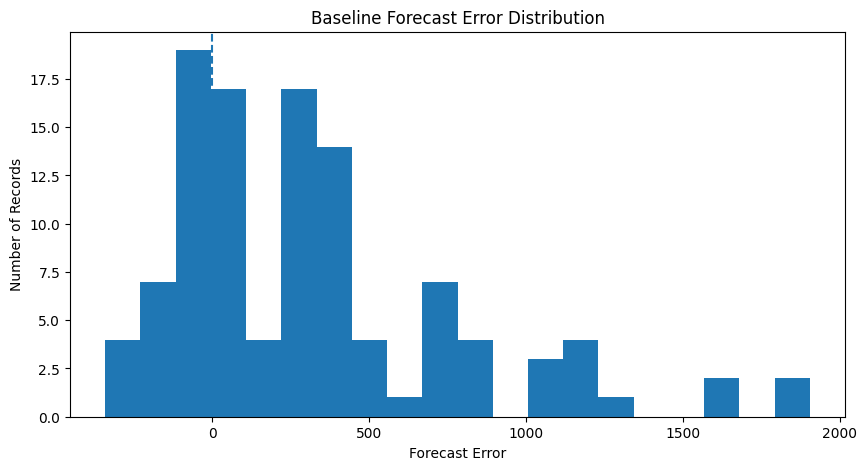

In [34]:
import matplotlib.pyplot as plt

# Plot distribution of forecast errors

plt.figure(figsize=(10, 5))

plt.hist(
    evaluation_df["error"],
    bins=20
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Baseline Forecast Error Distribution")
plt.xlabel("Forecast Error")
plt.ylabel("Number of Records")

plt.show()

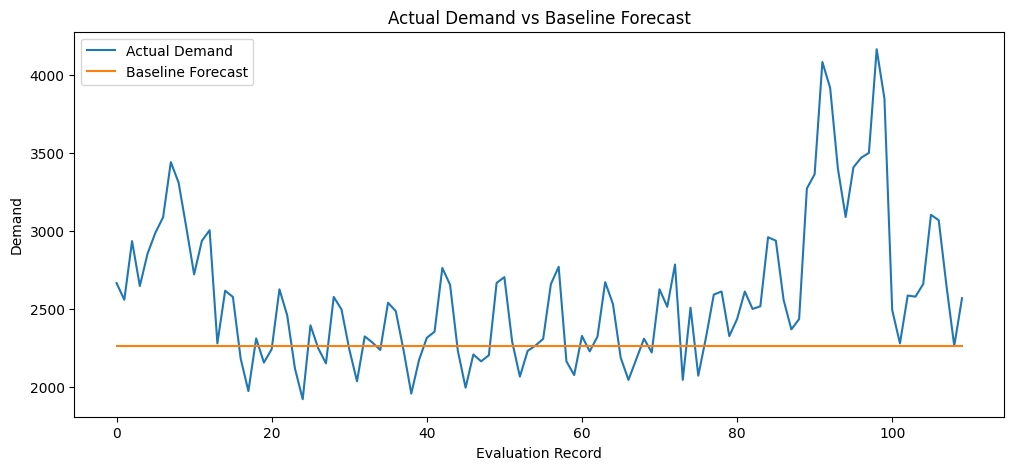

In [35]:
# Compare actual demand with baseline forecast

plt.figure(figsize=(12, 5))

plt.plot(
    evaluation_df["actual_demand"].values,
    label="Actual Demand"
)

plt.plot(
    evaluation_df["baseline_forecast"].values,
    label="Baseline Forecast"
)

plt.title("Actual Demand vs Baseline Forecast")
plt.xlabel("Evaluation Record")
plt.ylabel("Demand")

plt.legend()
plt.show()

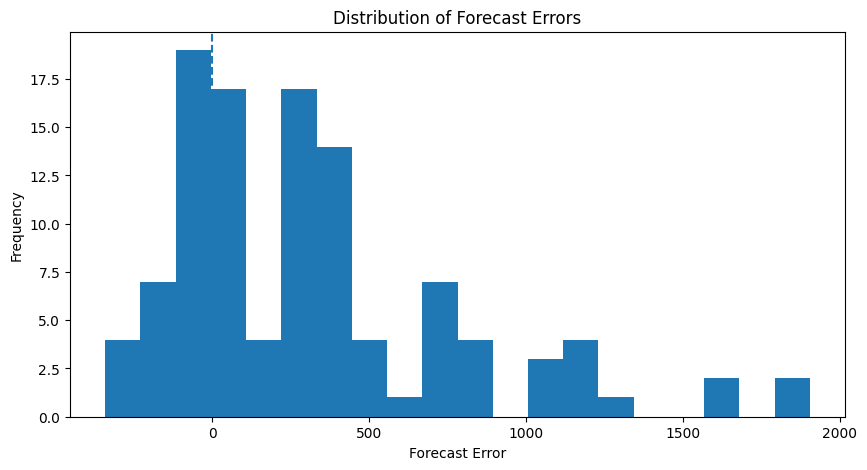

In [36]:
# Analyze the distribution of forecast errors

plt.figure(figsize=(10, 5))

plt.hist(
    evaluation_df["error"],
    bins=20
)

plt.title("Distribution of Forecast Errors")
plt.xlabel("Forecast Error")
plt.ylabel("Frequency")

plt.axvline(
    0,
    linestyle="--"
)

plt.show()

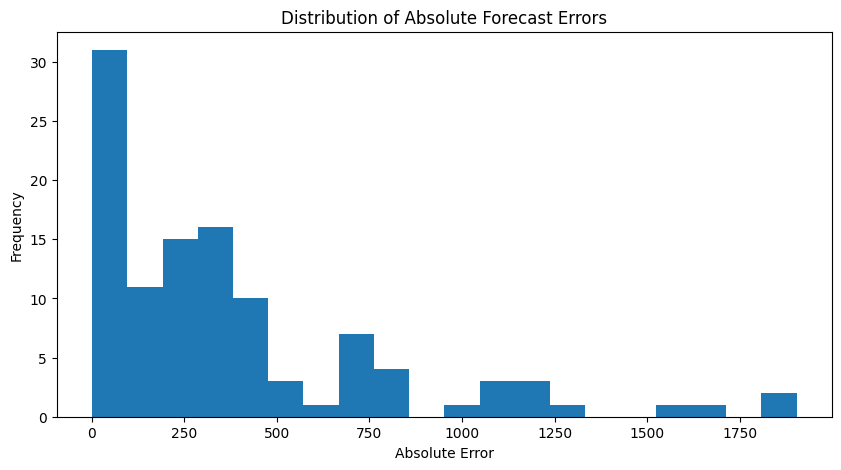

In [37]:
# Analyze the distribution of absolute forecast errors

plt.figure(figsize=(10, 5))

plt.hist(
    evaluation_df["absolute_error"],
    bins=20
)

plt.title("Distribution of Absolute Forecast Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")

plt.show()

In [38]:
# Calculate Mean Absolute Error (MAE)

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    evaluation_df["actual_demand"],
    evaluation_df["baseline_forecast"]
)

print("Mean Absolute Error (MAE):", round(mae, 2))

Mean Absolute Error (MAE): 383.2


In [39]:
# Calculate Root Mean Squared Error (RMSE)

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(
        evaluation_df["actual_demand"],
        evaluation_df["baseline_forecast"]
    )
)

print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Root Mean Squared Error (RMSE): 559.54


In [40]:
# Calculate Mean Absolute Percentage Error (MAPE)

non_zero_actual = (
    evaluation_df["actual_demand"] != 0
)

mape = (
    np.abs(
        (
            evaluation_df.loc[
                non_zero_actual,
                "actual_demand"
            ]
            -
            evaluation_df.loc[
                non_zero_actual,
                "baseline_forecast"
            ]
        )
        /
        evaluation_df.loc[
            non_zero_actual,
            "actual_demand"
        ]
    ).mean()
    * 100
)

print(
    "Mean Absolute Percentage Error (MAPE):",
    round(mape, 2),
    "%"
)

Mean Absolute Percentage Error (MAPE): 13.06 %


In [41]:
# Calculate Weighted Absolute Percentage Error (WAPE)

total_absolute_error = (
    evaluation_df["absolute_error"].sum()
)

total_actual_demand = (
    evaluation_df["actual_demand"].abs().sum()
)

if total_actual_demand != 0:
    wape = (
        total_absolute_error
        / total_actual_demand
        * 100
    )
else:
    wape = np.nan

print(
    "Weighted Absolute Percentage Error (WAPE):",
    round(wape, 2),
    "%"
)

Weighted Absolute Percentage Error (WAPE): 14.86 %


In [42]:
# Calculate R-squared score

from sklearn.metrics import r2_score

r2 = r2_score(
    evaluation_df["actual_demand"],
    evaluation_df["baseline_forecast"]
)

print(
    "R² Score:",
    round(r2, 4)
)

R² Score: -0.4701


In [43]:
# Analyze the distribution of forecasting errors

error_statistics = evaluation_df[
    [
        "error",
        "absolute_error"
    ]
].describe()

error_statistics

,error,absolute_error
count,110.000000,110.000000
mean,316.418182,383.200000
std,463.589968,409.591558
min,-341.000000,1.000000
25%,-19.750000,81.250000
50%,242.000000,268.000000
75%,455.500000,455.500000
max,1904.000000,1904.000000


In [44]:
# Identify records with the largest forecasting errors

largest_errors = (
    evaluation_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)

largest_errors

,actual_demand,baseline_forecast,error,absolute_error,cumulative_error,calculated_error,calculated_absolute_error,percentage_error
98,4166.0,2262.0,1904.0,1904.0,29589.0,1904.0,1904.0,45.703313
91,4084.0,2262.0,1822.0,1822.0,20470.0,1822.0,1822.0,44.613124
92,3918.0,2262.0,1656.0,1656.0,22126.0,1656.0,1656.0,42.266462
99,3849.0,2262.0,1587.0,1587.0,31176.0,1587.0,1587.0,41.231489
97,3501.0,2262.0,1239.0,1239.0,27685.0,1239.0,1239.0,35.389889
96,3470.0,2262.0,1208.0,1208.0,26446.0,1208.0,1208.0,34.812680
7,3442.0,2262.0,1180.0,1180.0,5084.0,1180.0,1180.0,34.282394
95,3408.0,2262.0,1146.0,1146.0,25238.0,1146.0,1146.0,33.626761
93,3400.0,2262.0,1138.0,1138.0,23264.0,1138.0,1138.0,33.470588
90,3364.0,2262.0,1102.0,1102.0,18648.0,1102.0,1102.0,32.758621


In [45]:
# Calculate forecast accuracy metrics for each record

evaluation_df["percentage_error"] = np.where(
    evaluation_df["actual_demand"] != 0,
    (
        evaluation_df["error"].abs()
        / evaluation_df["actual_demand"].abs()
    ) * 100,
    np.nan
)

evaluation_df["forecast_accuracy"] = np.where(
    evaluation_df["actual_demand"] != 0,
    (
        1 -
        (
            evaluation_df["error"].abs()
            / evaluation_df["actual_demand"].abs()
        )
    ) * 100,
    np.nan
)

print("Forecast accuracy calculations completed.")

display(
    evaluation_df[
        [
            "actual_demand",
            "baseline_forecast",
            "error",
            "percentage_error",
            "forecast_accuracy"
        ]
    ].head(10)
)

Forecast accuracy calculations completed.


,actual_demand,baseline_forecast,error,percentage_error,forecast_accuracy
0,2666.0,2262.0,404.0,15.153788,84.846212
1,2559.0,2262.0,297.0,11.606096,88.393904
2,2935.0,2262.0,673.0,22.930153,77.069847
3,2647.0,2262.0,385.0,14.544768,85.455232
4,2855.0,2262.0,593.0,20.770578,79.229422
5,2988.0,2262.0,726.0,24.297189,75.702811
6,3088.0,2262.0,826.0,26.748705,73.251295
7,3442.0,2262.0,1180.0,34.282394,65.717606
8,3310.0,2262.0,1048.0,31.661631,68.338369
9,3021.0,2262.0,759.0,25.124131,74.875869


In [46]:
# Create baseline model performance summary

baseline_performance = pd.DataFrame({
    "Model": ["Baseline Forecast"],
    "Evaluation Records": [len(evaluation_df)],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE (%)": [mape],
    "WAPE (%)": [wape],
    "R²": [r2],
    "Average Forecast Accuracy (%)": [
        evaluation_df["forecast_accuracy"].mean()
    ]
})

baseline_performance

,Model,Evaluation Records,MAE,RMSE,MAPE (%),WAPE (%),R²,Average Forecast Accuracy (%)
0,Baseline Forecast,110,383.2,559.537618,13.064334,14.861825,-0.470133,86.935666


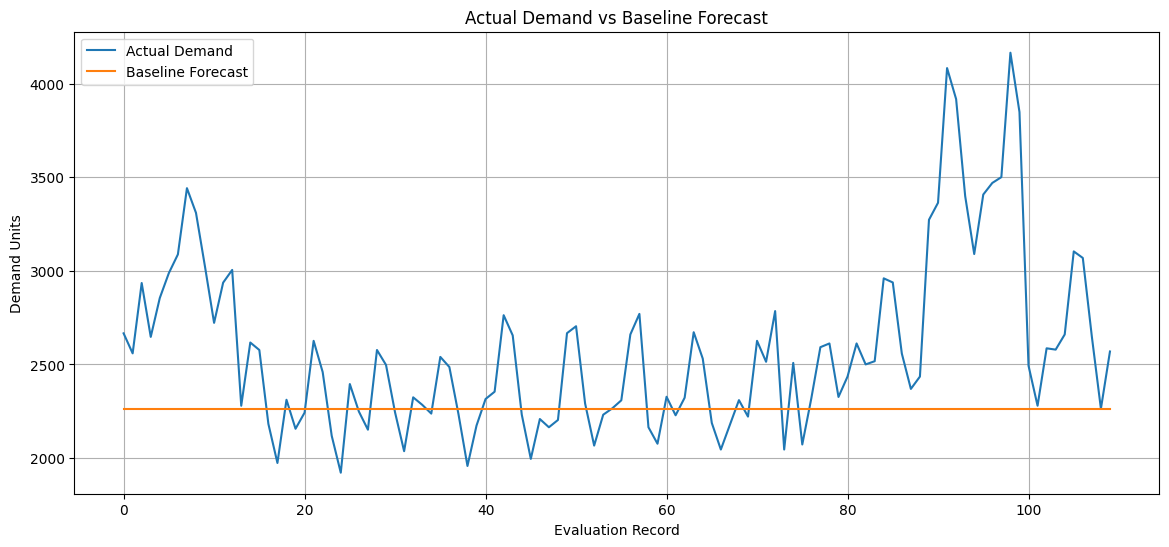

In [47]:
import matplotlib.pyplot as plt

# Plot actual demand vs baseline forecast

plt.figure(figsize=(14, 6))

plt.plot(
    evaluation_df.index,
    evaluation_df["actual_demand"],
    label="Actual Demand"
)

plt.plot(
    evaluation_df.index,
    evaluation_df["baseline_forecast"],
    label="Baseline Forecast"
)

plt.title("Actual Demand vs Baseline Forecast")
plt.xlabel("Evaluation Record")
plt.ylabel("Demand Units")
plt.legend()
plt.grid(True)

plt.show()

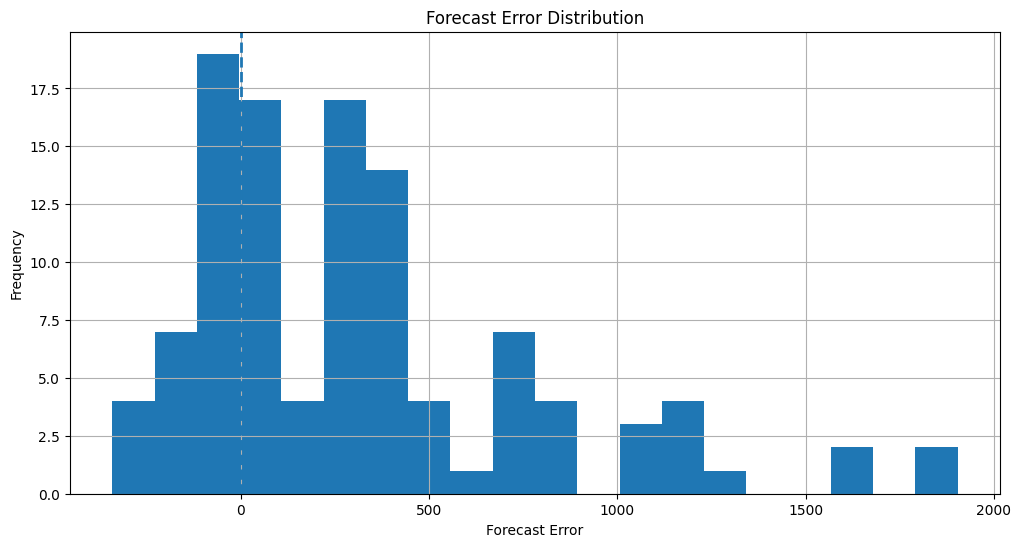

In [48]:
# Visualize forecast error distribution

plt.figure(figsize=(12, 6))

plt.hist(
    evaluation_df["error"],
    bins=20
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title("Forecast Error Distribution")
plt.xlabel("Forecast Error")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

In [49]:
# Save detailed evaluation results

import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)

evaluation_output_path = (
    "../data/processed/model_evaluation_details.csv"
)

evaluation_df.to_csv(
    evaluation_output_path,
    index=False
)

print(
    "Detailed evaluation results saved to:"
)

print(evaluation_output_path)

Detailed evaluation results saved to:
../data/processed/model_evaluation_details.csv


In [50]:
# Save model evaluation summary

summary_output_path = (
    "../data/processed/model_evaluation_summary.csv"
)

baseline_performance.to_csv(
    summary_output_path,
    index=False
)

print(
    "Model evaluation summary saved to:"
)

print(summary_output_path)

Model evaluation summary saved to:
../data/processed/model_evaluation_summary.csv


In [51]:
# Generate final model evaluation report

final_report = pd.DataFrame({
    "Metric": [
        "Evaluation Records",
        "Mean Absolute Error (MAE)",
        "Root Mean Squared Error (RMSE)",
        "Mean Absolute Percentage Error (MAPE)",
        "Weighted Absolute Percentage Error (WAPE)",
        "R² Score",
        "Average Forecast Accuracy"
    ],
    "Value": [
        len(evaluation_df),
        round(mae, 2),
        round(rmse, 2),
        round(mape, 2),
        round(wape, 2),
        round(r2, 4),
        round(
            evaluation_df["forecast_accuracy"].mean(),
            2
        )
    ]
})

final_report

,Metric,Value
0,Evaluation Records,110.0000
1,Mean Absolute Error (MAE),383.2000
2,Root Mean Squared Error (RMSE),559.5400
3,Mean Absolute Percentage Error (MAPE),13.0600
4,Weighted Absolute Percentage Error (WAPE),14.8600
5,R² Score,-0.4701
6,Average Forecast Accuracy,86.9400


In [52]:
# Final evaluation quality checks

print("===== MODEL EVALUATION QUALITY CHECK =====")

print(
    "Evaluation records:",
    len(evaluation_df)
)

print(
    "Missing actual demand:",
    evaluation_df["actual_demand"].isna().sum()
)

print(
    "Missing forecast:",
    evaluation_df["baseline_forecast"].isna().sum()
)

print(
    "MAE:",
    round(mae, 2)
)

print(
    "RMSE:",
    round(rmse, 2)
)

print(
    "MAPE:",
    round(mape, 2),
    "%"
)

print(
    "WAPE:",
    round(wape, 2),
    "%"
)

print(
    "R²:",
    round(r2, 4)
)

print("\nModel evaluation completed successfully.")

===== MODEL EVALUATION QUALITY CHECK =====
Evaluation records: 110
Missing actual demand: 0
Missing forecast: 0
MAE: 383.2
RMSE: 559.54
MAPE: 13.06 %
WAPE: 14.86 %
R²: -0.4701

Model evaluation completed successfully.


# Conclusion — Model Evaluation

The FORESIGHT baseline demand forecasting model has been evaluated using 110 forecast records.

### Evaluation Metrics

The model was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- Weighted Absolute Percentage Error (WAPE)
- R² Score
- Forecast accuracy

### Additional Analysis

The notebook also includes:

- Record-level percentage error
- Forecast accuracy
- Actual vs forecast visualization
- Forecast error distribution
- Detailed error analysis
- Baseline model performance summary

### Generated Outputs

The following files were generated:

- `model_evaluation_details.csv`
- `model_evaluation_summary.csv`

### Project Handoff

The evaluated baseline forecast can now be used as a benchmark for the FORESIGHT inventory intelligence pipeline.

Next stages can use the forecasting results together with inventory information to support:

- Inventory risk assessment
- Stockout identification
- Overstock identification
- Replenishment planning
- Inventory recommendations
- Dashboard development